# 使用二维卷积 SNN 训练 NinaPro 极性泊松脉冲

数据来自 `ninapro_data/raw_data_poisson_spikes/polarity_split/T_{T}`。每个样本原始形状为 `[32, T]`，模型内部按 `[16 个正极性, 16 个负极性]` 重塑为 `[2, 16, T]`，再使用普通 `Conv2d` 和 PLIF 神经元学习时空特征。

按照项目现有训练协议，每个 epoch 在测试集上评估并按测试准确率保存 `best.pt`。因此该结果属于 **test-selected checkpoint**，不应解释为完全无偏的泛化估计。

In [1]:
from pathlib import Path


def find_project_root():
    """从当前目录向上查找项目根目录。"""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir() and (candidate / "ninapro_data").is_dir():
            return candidate
    raise FileNotFoundError("未找到同时包含 src 与 ninapro_data 的项目根目录")


PROJECT_ROOT = find_project_root()

import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /root/autodl-tmp/NinaPro


## 1. 实验参数

In [2]:
# 修改 T 即可切换已有的泊松脉冲数据。
T = 40
AVAILABLE_TIME_STEPS = (40, 80, 120)

NUM_WORKERS = 8
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP = 1.0
WARMUP_EPOCHS = 5
SEED = 42
DETERMINISTIC = False
MIXED_PRECISION = True
EVAL_INTERVAL = 1
CHECKPOINT_INTERVAL = 5
TARGET_TEST_ACCURACY = 0.80
FAST_MODE = True
PREFER_CUPY = True
GPU_RESIDENT_DATA = True

INPUT_CHANNELS = 32
POLARITY_CHANNELS = 2
ELECTRODE_CHANNELS = 16
FEATURE_CHANNELS = (64, 128, 256)
NUM_CLASSES = 12
TAU = 2.0
DROPOUT_RATE = 0.2

RUN_OVERFIT_CHECK = False
OVERFIT_MAX_STEPS = 500
OVERFIT_TARGET_ACCURACY = 0.99
OVERFIT_SAMPLES_PER_CLASS = 2
RESUME_FROM = None

In [3]:
if T not in AVAILABLE_TIME_STEPS:
    raise ValueError(
        f"T={T} 没有对应的预编码数据，可选值为 {AVAILABLE_TIME_STEPS}"
    )

DATA_DIR = (
    PROJECT_ROOT
    / "ninapro_data"
    / "raw_data_poisson_spikes"
    / "polarity_split"
    / f"T_{T}"
)
MODEL_NAME = "NinaProCSNN"
EXPERIMENT_NAME = (
    f"{MODEL_NAME}_BATCH_SIZE{BATCH_SIZE}_LR{LEARNING_RATE}"
    f"_FEATURES{'-'.join(map(str, FEATURE_CHANNELS))}"
    f"_DROPOUT{DROPOUT_RATE}_TAU{TAU}_WD{WEIGHT_DECAY}"
)
OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "poisson_spikes_csnn"
    / f"T_{T}"
    / EXPERIMENT_NAME
)

print(f"DATA_DIR = {DATA_DIR}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

DATA_DIR = /root/autodl-tmp/NinaPro/ninapro_data/raw_data_poisson_spikes/polarity_split/T_40
OUTPUT_DIR = /root/autodl-tmp/NinaPro/outputs/poisson_spikes_csnn/T_40/NinaProCSNN_BATCH_SIZE128_LR0.002_FEATURES64-128-256_DROPOUT0.2_TAU2.0_WD0.0001


## 2. 随机种子与设备

In [4]:
from src.training import resolve_device, seed_everything

seed_everything(SEED, deterministic=DETERMINISTIC)
DEVICE = resolve_device()
print(f"DEVICE = {DEVICE}")

DEVICE = cuda


## 3. 加载二值泊松脉冲

In [5]:
import torch
from torch.utils.data import DataLoader

from src.data import NinaProWindowDataset

# 预编码数据保持 0/1，不应用原始 sEMG 数据使用的 Z-score。
train_dataset = NinaProWindowDataset(DATA_DIR / "train.npz", transform=None)
test_dataset = NinaProWindowDataset(DATA_DIR / "test.npz", transform=None)

expected_shape = (INPUT_CHANNELS, T)
for split_name, dataset in (("train", train_dataset), ("test", test_dataset)):
    sample, target = dataset[0]
    if tuple(sample.shape) != expected_shape:
        raise ValueError(
            f"{split_name} 样本形状应为 {expected_shape}，实际为 {tuple(sample.shape)}"
        )
    if sample.min() < 0 or sample.max() > 1:
        raise ValueError(f"{split_name} 数据不是 0/1 泊松脉冲")
    reshaped = sample.reshape(POLARITY_CHANNELS, ELECTRODE_CHANNELS, T)
    print(
        f"{split_name}: samples={len(dataset):,}, "
        f"stored={tuple(sample.shape)}, model_input={tuple(reshaped.shape)}"
    )

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
}
if NUM_WORKERS > 0:
    loader_options["persistent_workers"] = True

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=False,
    generator=torch.Generator().manual_seed(SEED),
    **loader_options,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    generator=torch.Generator().manual_seed(SEED + 1),
    **loader_options,
)

train: samples=17,839, stored=(32, 40), model_input=(2, 16, 40)
test: samples=8,787, stored=(32, 40), model_input=(2, 16, 40)


## 4. 二维卷积 SNN

In [6]:
from src.models import NinaProCSNN

model = NinaProCSNN(
    input_channels=INPUT_CHANNELS,
    polarity_channels=POLARITY_CHANNELS,
    electrode_channels=ELECTRODE_CHANNELS,
    feature_channels=FEATURE_CHANNELS,
    num_classes=NUM_CLASSES,
    tau=TAU,
    dropout_rate=DROPOUT_RATE,
)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f"parameters = {parameter_count:,}")

NinaProCSNN(
  input_channels=32, input_layout=(2, 16), feature_channels=(64, 128, 256), num_classes=12, tau=2.0, dropout_rate=0.2, learnable_tau=False, step_mode='m', backend='torch', auto_reset=True
  (blocks): ModuleList(
    (0): _ChannelConvSpikeBlock(
      (conv): Conv1d(2, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (normalization): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (neuron): LIFNode(
        v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
        (surrogate_function): ATan(alpha=2.0, spiking=True)
      )
      (dropout): Dropout(p=0.2)
    )
    (1): _ChannelConvSpikeBlock(
      (conv): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (normalization): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (neuron): LIFNode(
        v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=tor

## 5. 可选的单批次过拟合诊断

In [7]:
import copy

from src.training import overfit_one_batch

diagnostic_history = None
if RUN_OVERFIT_CHECK:
    diagnostic_indices = []
    for class_index in range(NUM_CLASSES):
        class_indices = torch.nonzero(
            train_dataset.labels == class_index,
            as_tuple=False,
        ).flatten()
        diagnostic_indices.extend(
            class_indices[:OVERFIT_SAMPLES_PER_CLASS].tolist()
        )
    diagnostic_samples = [train_dataset[index] for index in diagnostic_indices]
    diagnostic_batch = (
        torch.stack([sample for sample, _ in diagnostic_samples]),
        torch.stack([target for _, target in diagnostic_samples]),
    )
    diagnostic_model = copy.deepcopy(model)
    diagnostic_history = overfit_one_batch(
        diagnostic_model,
        diagnostic_batch,
        max_steps=OVERFIT_MAX_STEPS,
        target_accuracy=OVERFIT_TARGET_ACCURACY,
        learning_rate=LEARNING_RATE,
        gradient_clip=GRADIENT_CLIP,
        device=DEVICE,
    )
    final_diagnostic = diagnostic_history[-1]
    print(
        f"diagnostic steps={len(diagnostic_history)}, "
        f"loss={final_diagnostic['loss']:.4f}, "
        f"accuracy={final_diagnostic['accuracy'] * 100:.2f}%"
    )

## 6. 正式训练

In [8]:
from src.training import fit

CLASS_NAMES = [
    "Index flexion", "Index extension", "Middle flexion", "Middle extension",
    "Ring flexion", "Ring extension", "Little flexion", "Little extension",
    "Thumb adduction", "Thumb abduction", "Thumb flexion", "Thumb extension",
]
experiment_config = {
    "seed": SEED,
    "deterministic": DETERMINISTIC,
    "data_dir": str(DATA_DIR),
    "input_representation": "poisson_polarity_split",
    "input_layout_stored": "[B, 32, T]",
    "input_layout_model": "[B, 2, 16, T]",
    "normalization": "none_preserve_binary_spikes",
    "target_time_steps": T,
    "target_test_accuracy": TARGET_TEST_ACCURACY,
    "model": {
        "name": MODEL_NAME,
        "input_channels": INPUT_CHANNELS,
        "polarity_channels": POLARITY_CHANNELS,
        "electrode_channels": ELECTRODE_CHANNELS,
        "feature_channels": list(FEATURE_CHANNELS),
        "num_classes": NUM_CLASSES,
        "tau": TAU,
        "dropout_rate": DROPOUT_RATE,
        "parameter_count": parameter_count,
    },
}

history = fit(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    output_dir=OUTPUT_DIR,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    gradient_clip=GRADIENT_CLIP,
    device=DEVICE,
    mixed_precision=MIXED_PRECISION,
    normalization_state=None,
    config=experiment_config,
    resume_from=RESUME_FROM,
    class_names=CLASS_NAMES,
    warmup_epochs=WARMUP_EPOCHS,
    eval_interval=EVAL_INTERVAL,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    fast_mode=FAST_MODE,
    prefer_cupy=PREFER_CUPY,
    gpu_resident_data=GPU_RESIDENT_DATA,
)

device=cuda, amp=True, backend=spikingjelly-cupy, gpu_resident_data=True, batch_size=128, epochs=1..100


Train 001/100:   0%|          | 0/140 [00:00<?, ?it/s]

Test  001/100:   0%|          | 0/69 [00:00<?, ?it/s]

epoch 001/100 | train loss 2.4551, acc 9.65% | test loss 2.4478, acc 11.73% | lr 4.000e-04 | 4.46s *


Train 002/100:   0%|          | 0/140 [00:00<?, ?it/s]

...

epoch 099/100 | train loss 2.0758, acc 28.33% | test loss 2.1141, acc 25.94% | lr 2.186e-06 | 2.06s


Train 100/100:   0%|          | 0/140 [00:00<?, ?it/s]

Test  100/100:   0%|          | 0/69 [00:00<?, ?it/s]

epoch 100/100 | train loss 2.0757, acc 28.03% | test loss 2.1121, acc 25.96% | lr 5.467e-07 | 2.18s


Best test:   0%|          | 0/69 [00:00<?, ?it/s]

## 7. 最佳测试结果

best epoch       = 19
test accuracy    = 31.83%
macro precision  = 33.71%
macro recall     = 32.11%
macro F1         = 31.53%
80% target reached = False (target=80.00%)
注意：以上结果来自 test-selected checkpoint。


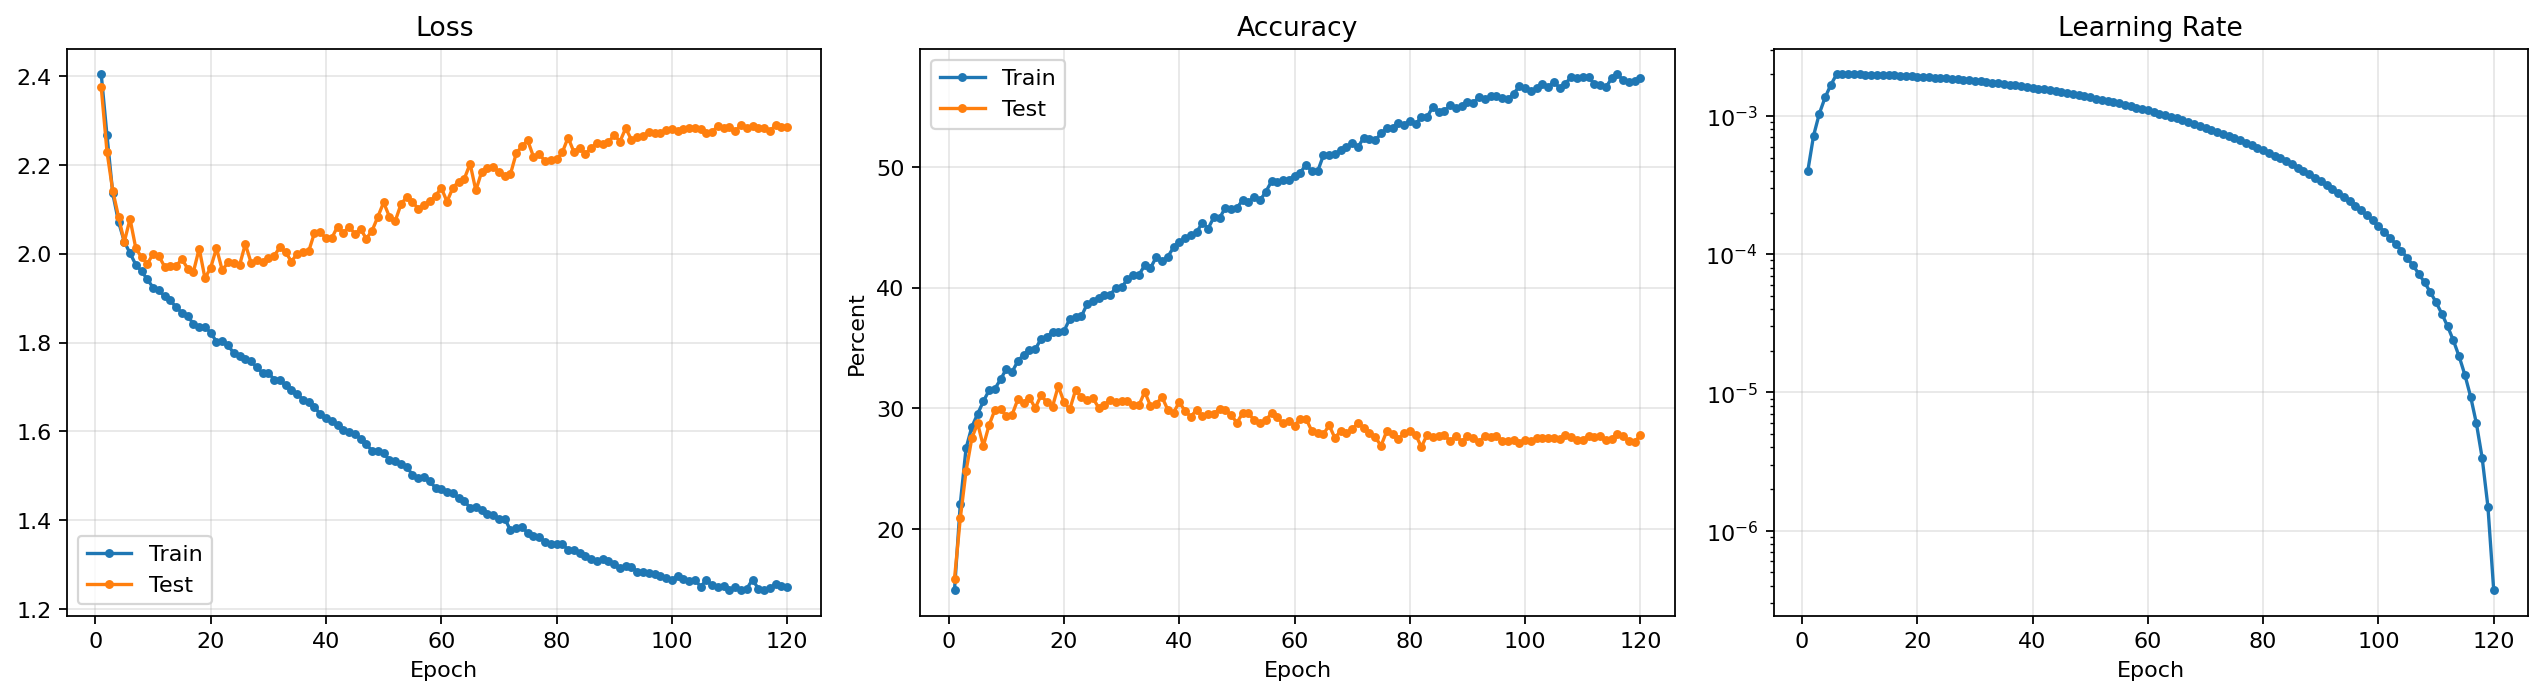

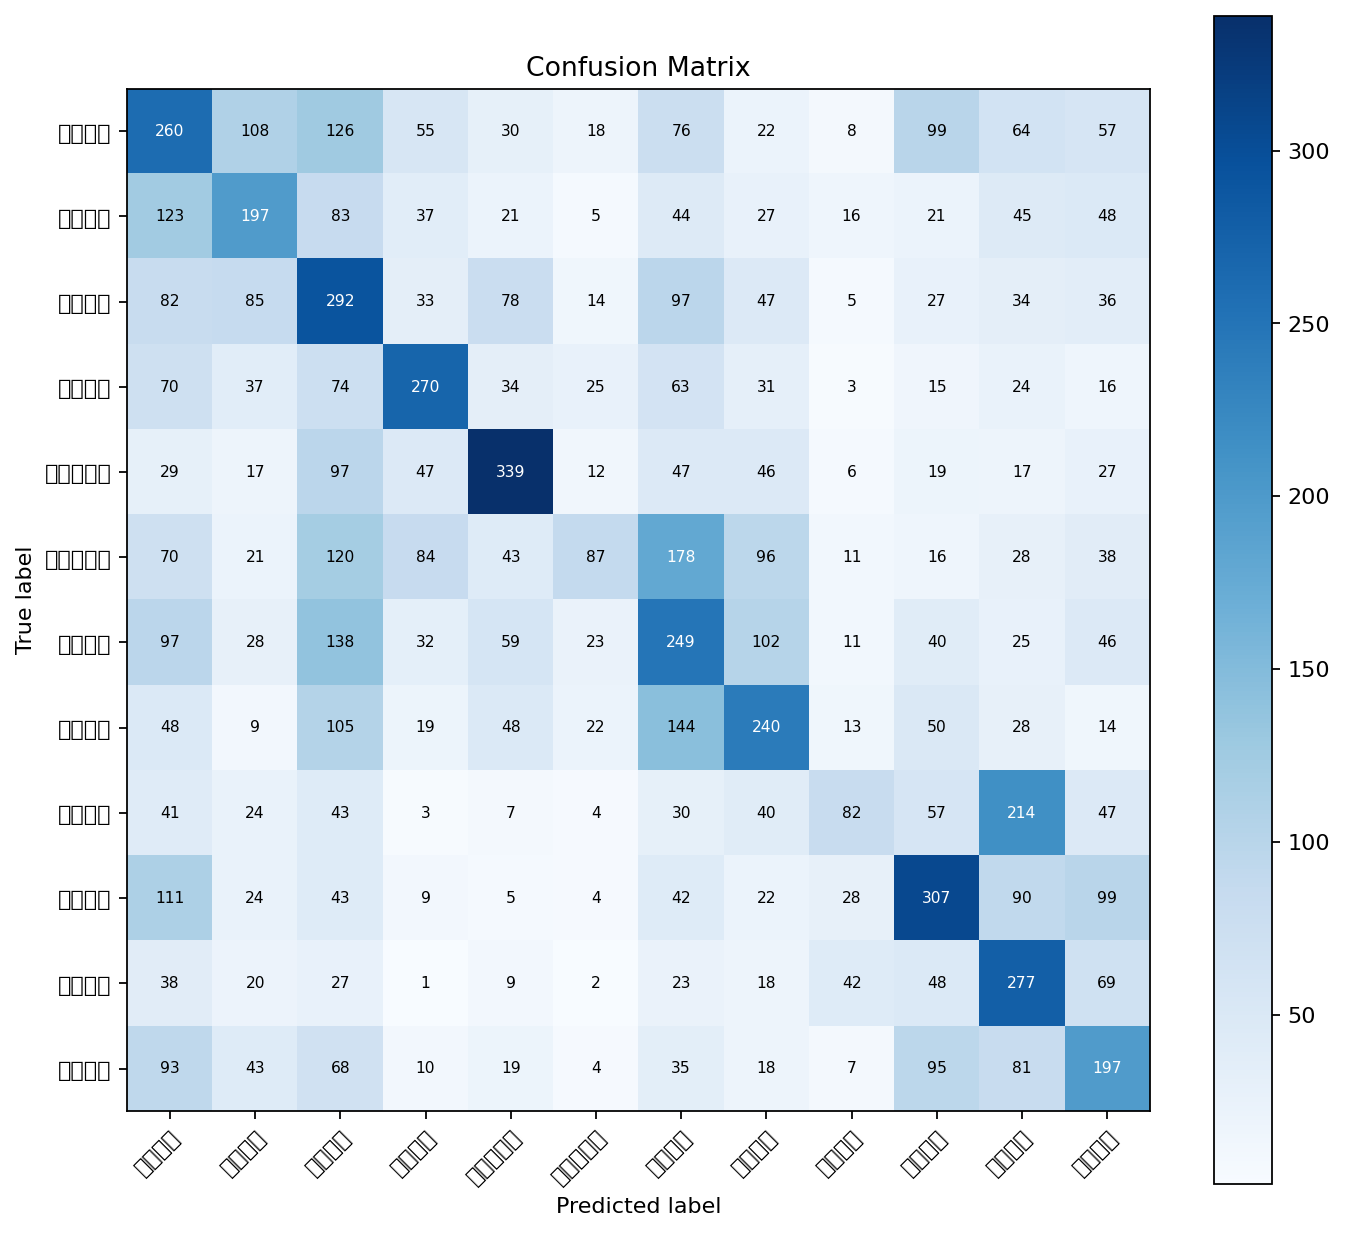

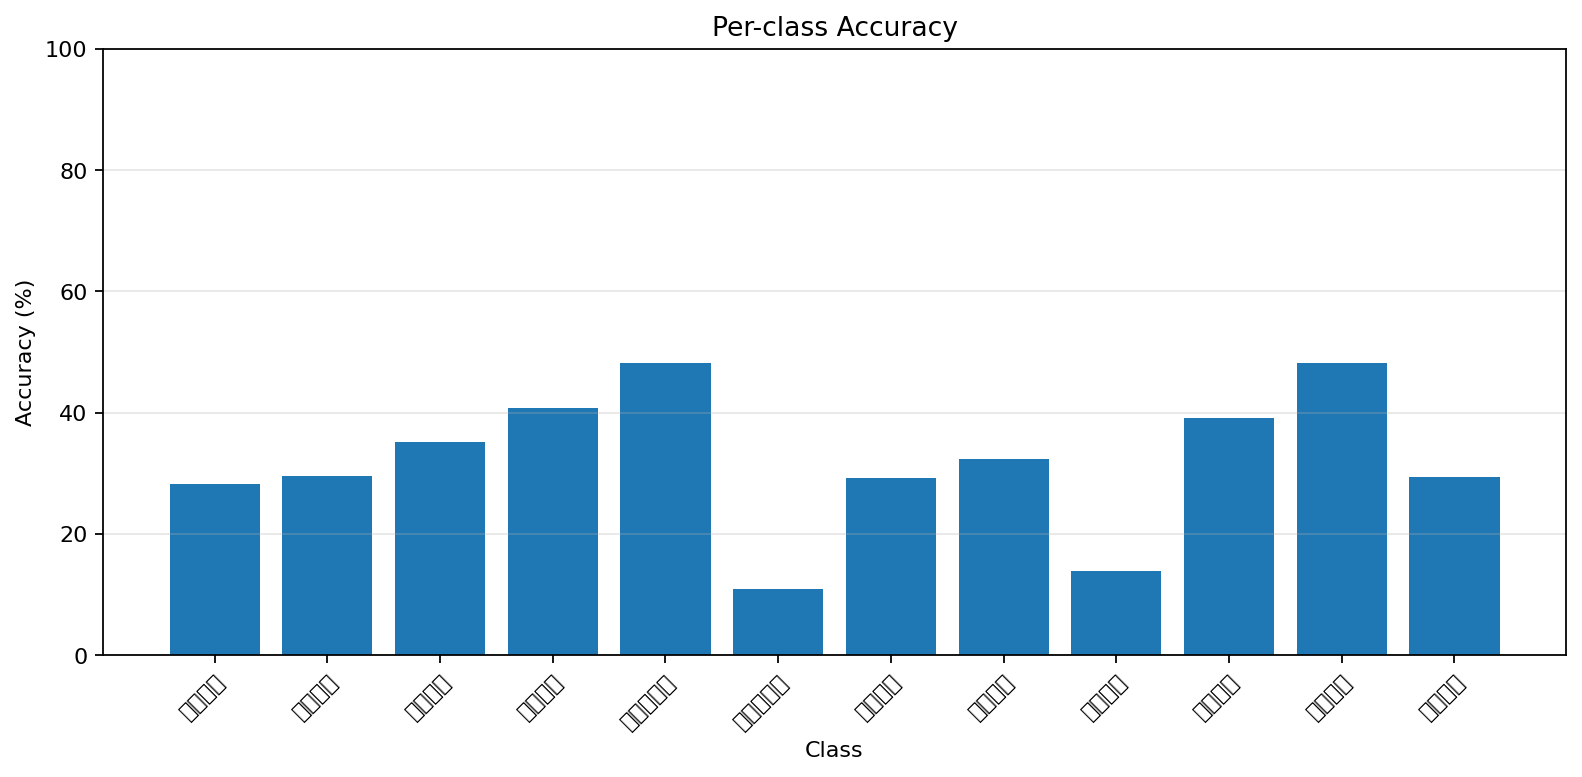

In [10]:
import json
from IPython.display import Image, display

metrics_path = OUTPUT_DIR / "metrics.json"
best_metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
print(f"best epoch       = {best_metrics['best_epoch']}")
print(f"test accuracy    = {best_metrics['accuracy'] * 100:.2f}%")
print(f"macro precision  = {best_metrics['macro_precision'] * 100:.2f}%")
print(f"macro recall     = {best_metrics['macro_recall'] * 100:.2f}%")
print(f"macro F1         = {best_metrics['macro_f1'] * 100:.2f}%")
target_reached = best_metrics["accuracy"] >= TARGET_TEST_ACCURACY
print(
    f"80% target reached = {target_reached} "
    f"(target={TARGET_TEST_ACCURACY * 100:.2f}%)"
)
print("注意：以上结果来自 test-selected checkpoint。")

for filename in (
    "training_curves.png",
    "confusion_matrix.png",
    "per_class_accuracy.png",
):
    display(Image(filename=str(OUTPUT_DIR / "figures" / filename)))